# scRNA-seq on a simulated tumour

One cm-scale ductal-field tumour, dissociated and run through two scRNA protocols. Everything the
assay hides — cell type, clone, gene-program activity, copy number — is still on hand, so every
plot can be checked against the answer.

1. **Ground truth** — what the tumour actually is.
2. **Dissociation** — the sample the assays see.
3. **10x** — parameters, library size, mean-variance, a standard scanpy analysis, and inferCNV.
4. **Smart-seq3** — the same, plus the plate/well structure a plate protocol adds.
5. **Estimating the parameters** from a real dataset (PBMC3k).

In [1]:
%matplotlib inline
import os, sys, tempfile, warnings

warnings.filterwarnings("ignore", message=".*IProgress not found.*")
NB_DIR = os.getcwd()
REPO = os.path.abspath(os.path.join(NB_DIR, ".."))
sys.path.insert(0, NB_DIR)
sys.path.insert(0, os.path.join(REPO, "validation"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import scanpy as sc
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

import base_sim as B
import integration_common as C
from iscc.integrations import to_anndata, clones_from_clades, clone_summary
from iscc.sample import Resection
from iscc.data import scRNA, estimate_rna
from iscc.data.rna import PROTOCOL_PRESETS

sc.settings.verbosity = 0
np.random.seed(0)

# One realistic tumour: a cm-scale DCIS->IDC lesion on a ductal field, with the gene-program layer on.
tumor = B.grow_base_tumor()
print(f"{sum(tumor.genotypes_counts.values()):,} live cells, "
      f"{len(tumor.cell_data['cell_type']):,} materialised, grid {tumor.grid_size}")

345,990 live cells, 7,917 materialised, grid 170


## 1. Ground truth

`to_anndata(tumor)` packs the whole tumour into one AnnData: expression in `X`, gene-program
activity in `obsm["program"]`, tissue coordinates in `obsm["spatial"]`, and cell type / clone /
evolutionary traits in `obs`. Clones are clades of the true lineage tree
(`clones_from_clades`) — the same definition the DNA and spatial notebooks use.

In [2]:
tissue = to_anndata(tumor, layers=())          # layers=() keeps it light; SNV/CNV layers are available
progs = list(tissue.uns["program_names"])
tissue.obs[progs] = np.asarray(tissue.obsm["program"])   # programs also as obs columns, for plotting

print(tissue)
print("\ncell types:", tissue.obs["cell_type"].value_counts().to_dict())
print(f"clones: {tissue.uns['clone_n_clones']} clades with >= {tissue.uns['clone_min_cells']} cells; "
      f"{tissue.uns['clone_other_frac']:.0%} of cancer cells sit on the ancestral backbone ('other')")

AnnData object with n_obs × n_vars = 7917 × 6000
    obs: 'genotype', 'cell_type', 'clone', 'division_rate', 'death_rate', 'dispersal_rate', 'treatment_resistance', 'immune_resistance', 'breach', 'stromal_survival', 'met_survival', 'viability', 'n_mut_onc', 'n_mut_tsg', 'n_mut_disp', 'n_mut_ir', 'n_mut_tr', 'n_mut_breach', 'n_mut_ss', 'n_mut_ms', 'deme_id', 'is_wgd', 'gland_id', 'row', 'col', 'proliferation', 'emt', 'hypoxia', 'drug_resistance', 'immune_evasion', 'program_5'
    var: 'driver_types', 'dispersal_types', 'treatment_resistance_types', 'immune_resistance_types', 'breach_types', 'stromal_survival_types', 'met_survival_types', 'germline_types', 'segment', 'position_in_segment', 'dosage_sensitivity', 'snv_class', 'snv_exp_effect', 'snv_class_name'
    uns: 'spatial_axes', 'program_names', 'source', 'clone_tree', 'clone_tree_newick', 'trace_counts', 'grid_size', 'seed', 'config', 'clone_definition', 'clone_definition_doc', 'clone_min_cells', 'clone_min_cells_mode', 'clone_n_clo

### Programs by cell type, and by clone

Six gene programs drive the expression. Cell type is the dominant split; within the cancer cells the
clones differ much more subtly.

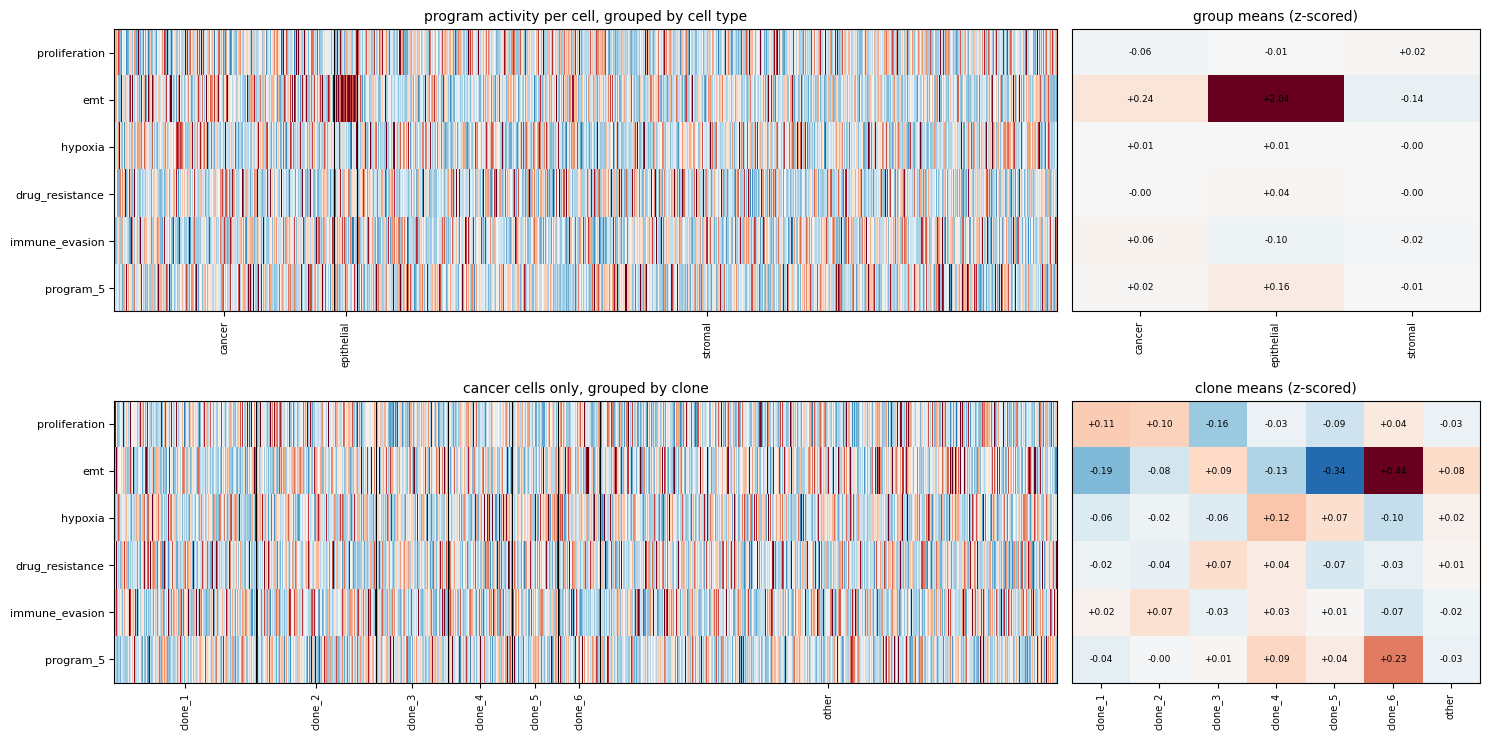

In [3]:
def zscored(ad):
    Z = ad.obs[progs]
    return (Z - Z.mean()) / (Z.std() + 1e-9)

def program_heatmap(ad, group, ax, title):
    Z = zscored(ad)
    lab = ad.obs[group].astype(str)
    order = lab.sort_values(kind="stable").index
    ax.imshow(Z.loc[order].values.T, aspect="auto", cmap="RdBu_r", vmin=-2.5, vmax=2.5,
              interpolation="nearest")
    s = lab.loc[order]
    edges = np.flatnonzero(s.values[1:] != s.values[:-1]) + 1
    starts, ends = np.r_[0, edges], np.r_[edges, len(s)]
    for e in edges:
        ax.axvline(e, color="k", lw=0.8)
    ax.set_yticks(range(len(progs))); ax.set_yticklabels(progs, fontsize=8)
    ax.set_xticks((starts + ends) / 2); ax.set_xticklabels(s.values[starts], rotation=90, fontsize=7)
    ax.set_title(title, fontsize=10)

def program_means(ad, group, ax, title):
    M = zscored(ad).groupby(ad.obs[group].astype(str).values).mean().T
    v = np.abs(M.values).max()
    ax.imshow(M.values, cmap="RdBu_r", vmin=-v, vmax=v, aspect="auto", interpolation="nearest")
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, f"{M.values[i, j]:+.2f}", ha="center", va="center", fontsize=6.5)
    ax.set_yticks([]); ax.set_xticks(range(M.shape[1]))
    ax.set_xticklabels(M.columns, rotation=90, fontsize=7)
    ax.set_title(title, fontsize=10)

fig, axes = plt.subplots(2, 2, figsize=(15, 7.5), gridspec_kw={"width_ratios": [3, 1.3]})
cancer = tissue[tissue.obs["cell_type"] == "cancer"]
program_heatmap(tissue, "cell_type", axes[0, 0], "program activity per cell, grouped by cell type")
program_means(tissue, "cell_type", axes[0, 1], "group means (z-scored)")
program_heatmap(cancer, "clone", axes[1, 0], "cancer cells only, grouped by clone")
program_means(cancer, "clone", axes[1, 1], "clone means (z-scored)")
plt.tight_layout()

Cell type dominates: epithelial cells sit eight standard deviations' worth of `emt` above cancer
cells, and cancer and stroma part company on most programs. Between clones the means barely move — a first
warning that clone identity is not an expression cluster.

### Programs in space

Every cell at its tissue coordinate, coloured by each program. The dense clusters are the ducts;
the sparse background is stroma.

,proliferation,emt,hypoxia,drug_resistance,immune_evasion,program_5
in duct,0.45,1.52,0.52,0.52,0.53,0.58
stroma,0.50,0.52,0.49,0.49,0.52,0.50


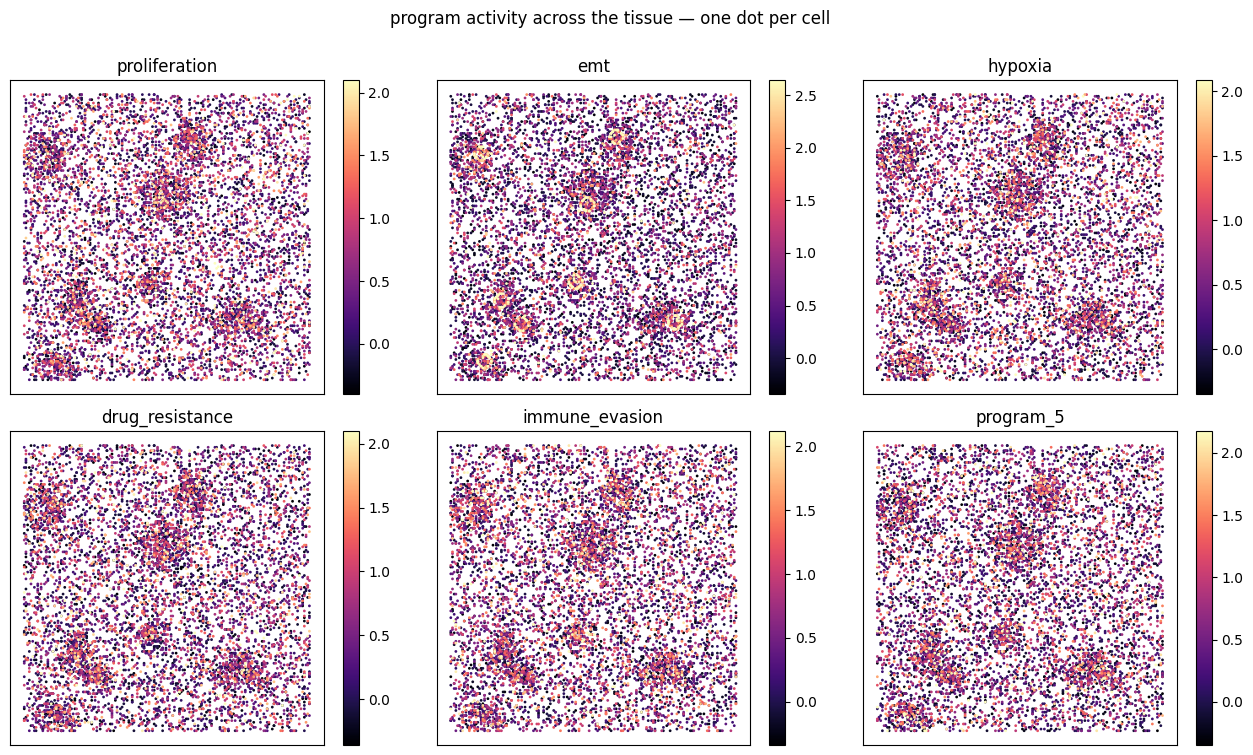

In [4]:
xy = tissue.obsm["spatial"]                    # (x, y) tissue coordinates

fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
for name, ax in zip(progs, axes.ravel()):
    v = tissue.obs[name].values
    o = np.argsort(v)                          # draw the bright cells last
    lo, hi = np.percentile(v, [2, 98])
    pts = ax.scatter(xy[o, 0], xy[o, 1], c=v[o], s=4, cmap="magma", vmin=lo, vmax=hi, linewidths=0)
    ax.set(title=name, xticks=[], yticks=[], aspect="equal")
    plt.colorbar(pts, ax=ax, fraction=0.046)
fig.suptitle("program activity across the tissue — one dot per cell", y=1.0)
plt.tight_layout()

site = np.where(tissue.obs["gland_id"] >= 0, "in duct", "stroma")
display(tissue.obs.groupby(site)[progs].mean().round(2))

`emt` is the one program with strong spatial structure: it is three times higher inside a duct than
in the surrounding stroma, because the invasive program is driven both by the `breach` mutation and
by the epithelial niche. The other five are spatially flat at this resolution.

### Trait values

`clone_summary` says what each clone carries; the per-clone means show how those mutations translate
into division rate and into the two compartment traits (`breach` = can cross the duct wall,
`stromal_survival` = fit once it has).

In [5]:
clones = clones_from_clades(tumor, min_cells=int(tissue.uns["clone_min_cells"]))
display(clone_summary(tumor, clones)[["n_cells", "genotype", "traits"]])

traits = ["division_rate", "breach", "stromal_survival", "n_mut_onc", "n_mut_tsg", "n_mut_breach"]
display(tissue.obs.groupby("clone", observed=True)[traits].mean().round(3))

,n_cells,genotype,traits
clone,,,
clone_1,276,7417,2 oncogene
clone_2,234,65,2 oncogene
clone_3,141,6,"2 oncogene, 1 immune-resistance"
clone_4,126,19,2 oncogene
clone_5,90,1597,"3 oncogene, 1 TSG"
clone_6,81,145,2 oncogene
other,894,<NA>,<NA>


,division_rate,breach,stromal_survival,n_mut_onc,n_mut_tsg,n_mut_breach
clone,,,,,,
clone_1,0.758,0.060,0.275,3.011,0.417,0.576
clone_2,0.791,0.078,0.195,3.171,0.594,0.513
clone_3,0.554,0.147,0.546,3.021,0.440,0.851
clone_4,0.704,0.100,0.295,4.056,0.571,1.341
clone_5,0.633,0.046,0.496,3.178,2.644,1.111
clone_6,0.808,0.045,0.171,3.284,1.802,0.889
other,0.588,0.157,0.455,2.617,0.728,0.506


### The program x gene loading matrix

`tumor.program_truth['loading']` is the dictionary the expression was generated from: which genes
each program turns up or down. It is what a program-discovery method (cNMF, scDEF, ...) is trying
to recover.

140 of 6000 genes carry a program loading; 1.07 programs per gene on average


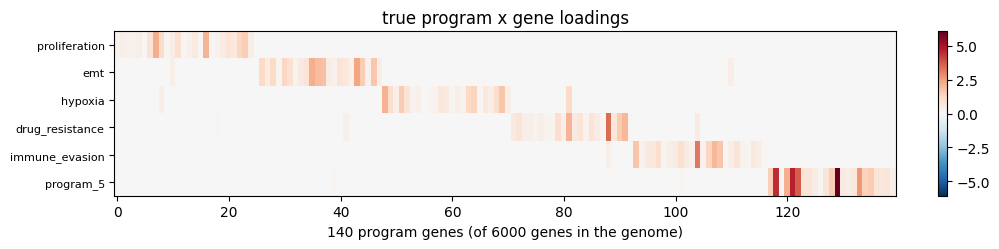

In [6]:
L = pd.DataFrame(np.asarray(tissue.varm["program_loading"]), index=tissue.var_names, columns=progs)
Lg = L.loc[(L != 0).any(axis=1)]
Lg = Lg.iloc[np.argsort(Lg.values.argmax(axis=1), kind="stable")]     # group genes by their program

fig, ax = plt.subplots(figsize=(10, 2.6))
v = np.abs(Lg.values).max()
im = ax.imshow(Lg.values.T, aspect="auto", cmap="RdBu_r", vmin=-v, vmax=v, interpolation="nearest")
ax.set_yticks(range(len(progs))); ax.set_yticklabels(progs, fontsize=8)
ax.set_xlabel(f"{Lg.shape[0]} program genes (of {L.shape[0]} genes in the genome)")
ax.set_title("true program x gene loadings")
plt.colorbar(im, ax=ax, fraction=0.02)
plt.tight_layout()
print(f"{Lg.shape[0]} of {L.shape[0]} genes carry a program loading; "
      f"{(Lg.values != 0).sum(1).mean():.2f} programs per gene on average")

## 2. Dissociation

`bisect` cuts the resected specimen in two; `dissociate` turns one half into a per-cell table at full
column depth — a mixture of malignant, epithelial and stromal cells, exactly what goes into a droplet
or onto a plate. The other half is still there for a DNA or a spatial assay.

`install=True` makes this sample the tumour's own cell table, so `to_anndata(tumor)` and
`clones_from_clades` now describe **precisely the cells we are about to assay**. Clone labels are
re-derived on this half, so they are numbered independently of section 1.

In [7]:
specimen = Resection(tumor)
piece, remainder = specimen.bisect(frac=0.5)         # cut it; half goes to scRNA
disso = specimen.dissociate(piece, max_cells=8000, install=True)
print(f"specimen cut into {len(piece)} + {len(remainder)} demes; the first half goes to scRNA")
truth = to_anndata(tumor, layers=())                 # ground truth of the dissociated cells
truth.obs[progs] = np.asarray(truth.obsm["program"])

print(f"{len(truth):,} dissociated cells x {truth.n_vars} genes")
print("cell types:", truth.obs["cell_type"].value_counts().to_dict())
print(f"tumour purity: {(truth.obs['cell_type'] == 'cancer').mean():.0%} of the cells are malignant")
print(f"clones: {truth.uns['clone_n_clones']} (min {truth.uns['clone_min_cells']} cells each)")
display(truth.obs["clone"].value_counts().to_frame("cells").T)

specimen cut into 14450 + 14450 demes; the first half goes to scRNA


7,931 dissociated cells x 6000 genes
cell types: {'stromal': 5437, 'cancer': 2229, 'epithelial': 265}
tumour purity: 28% of the cells are malignant
clones: 9 (min 80 cells each)


clone,other,clone_1,clone_2,clone_3,clone_4,clone_5,clone_6,clone_7,clone_8,clone_9
cells,1272,180,132,112,96,95,92,87,83,80


## 3. 10x

### The parameters that matter

| parameter | what it does |
|---|---|
| `mu_lib` / `sigma_lib` | mean sequencing depth per cell, and its cell-to-cell spread |
| `dispersion` | negative-binomial overdispersion: `var = mu + dispersion * mu^2` |
| `dropout_mid` / `dropout_shape` | zero-inflation of low-expression genes |
| `ambient_frac` | fraction of each library drawn from the pooled "soup" |
| `doublet_rate` | fraction of barcodes that are two cells |
| `sigma_batch` / `depth_batch_sigma` | per-gene and per-batch technical signature |

Each protocol is a preset over exactly these knobs.

In [8]:
display(pd.DataFrame(PROTOCOL_PRESETS).T)

,sigma_batch,mu_lib,sigma_lib,dispersion,ambient_frac,doublet_rate,dropout_mid,dropout_shape,well_sigma,n_wells,n_plates,plate_sigma,depth_batch_sigma,kappa
10x,0.1,4000.0,0.35,0.30,0.050,0.05,1.5,1.0,0.00,0.0,0.0,0.0,0.05,50.0
smartseq3,0.1,8000.0,0.45,0.15,0.005,0.01,0.0,1.0,0.15,384.0,0.0,0.0,0.05,50.0


### Coverage and dispersion

Ambient counts and doublets are switched off here (`ambient_frac=0, doublet_rate=0,
depth_batch_sigma=0`) so the depth effect is not confounded by them.

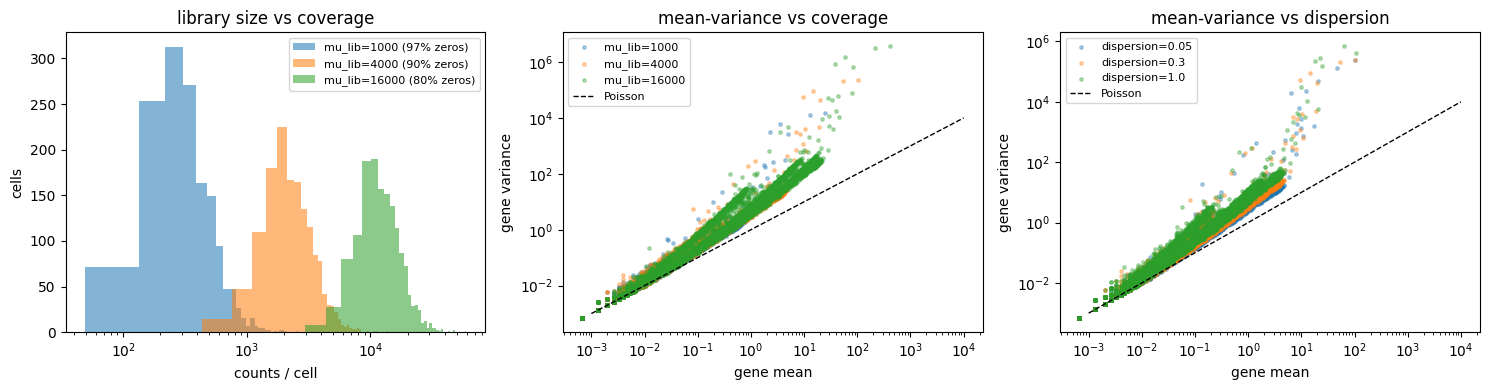

In [9]:
clean = dict(ambient_frac=0, doublet_rate=0, depth_batch_sigma=0)
sub = list(truth.obs_names[:1500])
lim = np.array([1e-3, 1e4])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for mu in [1000, 4000, 16000]:
    a = scRNA(protocol="10x", mu_lib=mu, seed=1, **clean).run(disso, cell_subset=sub).to_anndata()
    axes[0].hist(a.obs["n_counts"], bins=40, alpha=0.55,
                 label=f"mu_lib={mu} ({(a.X == 0).mean():.0%} zeros)")
    axes[1].scatter(a.X.mean(0), a.X.var(0), s=6, alpha=0.35, label=f"mu_lib={mu}")
for phi in [0.05, 0.3, 1.0]:
    a = scRNA(protocol="10x", dispersion=phi, seed=1, **clean).run(disso, cell_subset=sub).to_anndata()
    axes[2].scatter(a.X.mean(0), a.X.var(0), s=6, alpha=0.35, label=f"dispersion={phi}")

axes[0].set(xscale="log", xlabel="counts / cell", ylabel="cells", title="library size vs coverage")
for ax, ttl in [(axes[1], "mean-variance vs coverage"), (axes[2], "mean-variance vs dispersion")]:
    ax.plot(lim, lim, "k--", lw=1, label="Poisson")
    ax.set(xscale="log", yscale="log", xlabel="gene mean", ylabel="gene variance", title=ttl)
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()

Coverage shifts the library-size distribution and moves every gene along the mean-variance line;
dispersion tilts that line away from Poisson. Those are the two things `estimate_rna` reads back off
real data in section 5.

### A 10x run, and standard scanpy on it

The assay returns an AnnData directly. We copy the ground-truth labels onto it by cell id — the
assay's own `clone` column is the raw genotype, far too fine-grained to colour by.

median 2481 counts and 637 genes per cell; 89% zeros; 5.1% doublets; QC dropped 40 cells


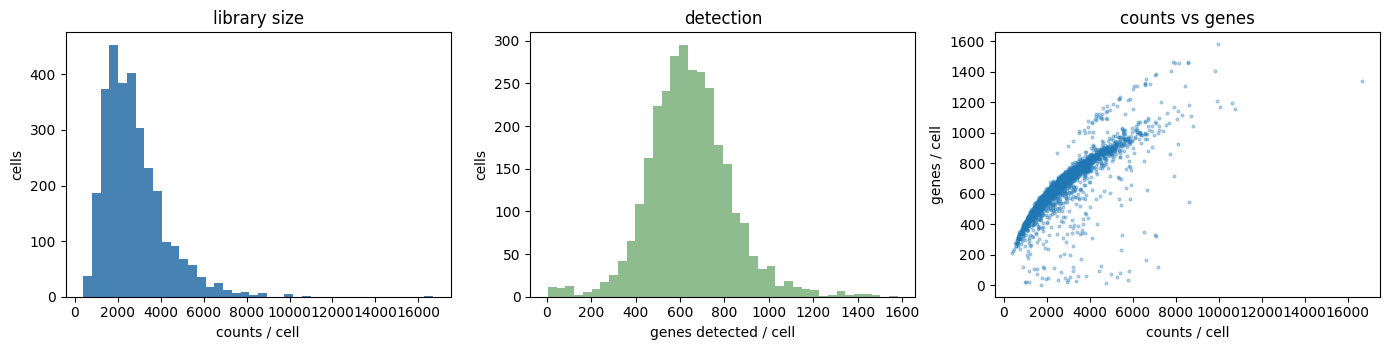

In [10]:
tenx = scRNA(protocol="10x", n_cells=3000, seed=1).run(disso).to_anndata()
tenx.obs["cell_type"] = truth.obs["cell_type"].reindex(tenx.obs_names).values
tenx.obs["clone"] = truth.obs["clone"].reindex(tenx.obs_names).values

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
axes[0].hist(tenx.obs["n_counts"], bins=40, color="steelblue")
axes[0].set(xlabel="counts / cell", ylabel="cells", title="library size")
axes[1].hist(tenx.obs["n_genes"], bins=40, color="darkseagreen")
axes[1].set(xlabel="genes detected / cell", ylabel="cells", title="detection")
axes[2].scatter(tenx.obs["n_counts"], tenx.obs["n_genes"], s=4, alpha=0.3)
axes[2].set(xlabel="counts / cell", ylabel="genes / cell", title="counts vs genes")
plt.tight_layout()

before = tenx.n_obs
sc.pp.filter_cells(tenx, min_genes=200)
print(f"median {tenx.obs['n_counts'].median():.0f} counts and {tenx.obs['n_genes'].median():.0f} "
      f"genes per cell; {(tenx.X == 0).mean():.0%} zeros; "
      f"{tenx.obs['is_doublet'].mean():.1%} doublets; QC dropped {before - tenx.n_obs} cells")

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


,sil_cell_type,sil_clone,knn_clone,knn_chance
10x counts,0.669,-0.063,0.408,0.348
ground truth,0.905,-0.092,0.593,0.348


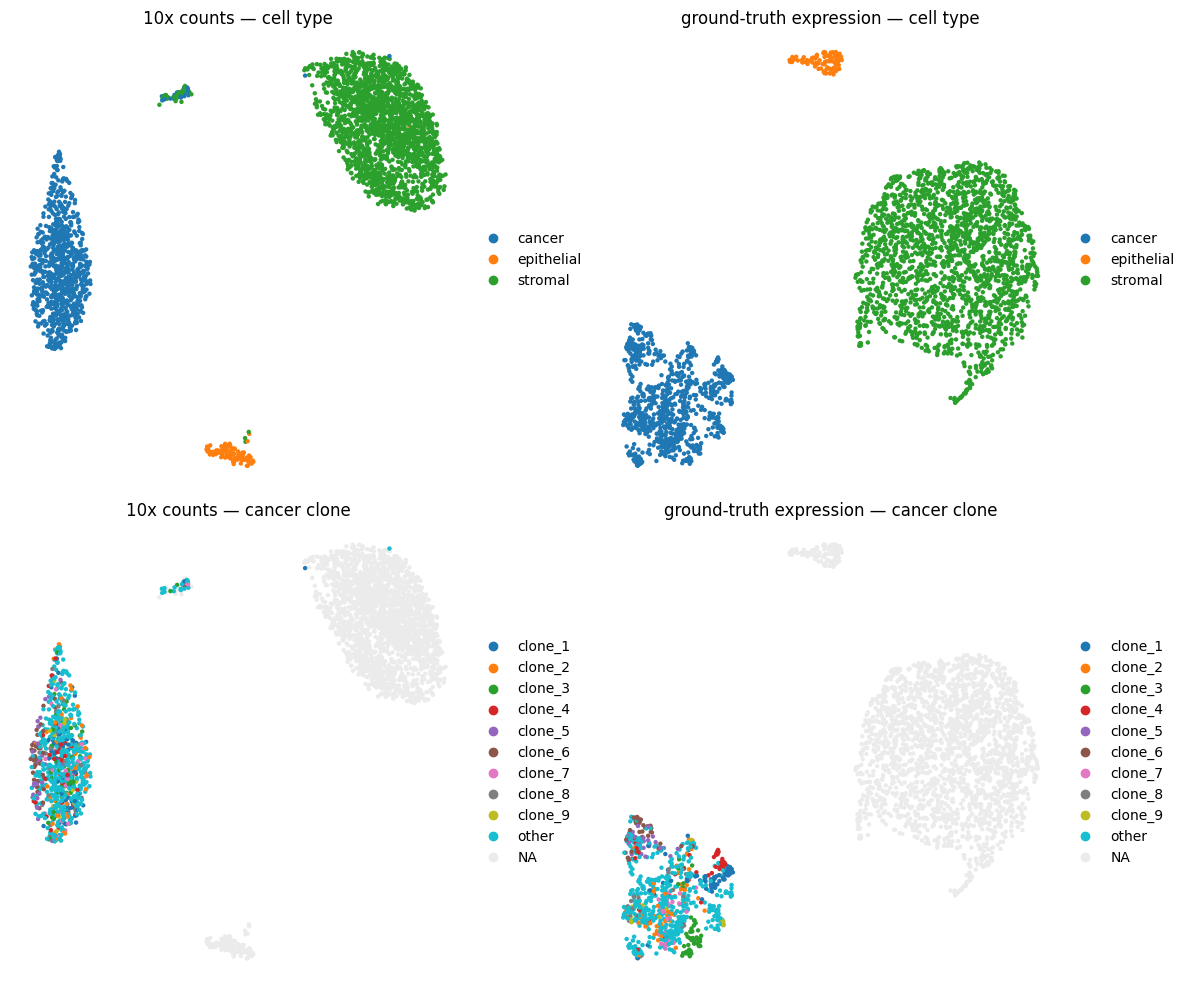

In [11]:
def umap_of(a, seed=0):
    a = a.copy()
    a.X = np.asarray(a.X, dtype=np.float32)
    sc.pp.normalize_total(a, target_sum=1e4)
    sc.pp.log1p(a)
    sc.pp.pca(a, n_comps=30)
    sc.pp.neighbors(a, n_neighbors=15, random_state=seed)
    sc.tl.umap(a, random_state=seed)
    return a

def separation(a, key):
    # Silhouette of a label in PCA space: 1 = perfectly separated, 0 = no structure.
    m = a.obs[key].notna().values
    lab = a.obs[key][m].astype(str)
    return float(silhouette_score(a.obsm["X_pca"][m], lab)) if lab.nunique() > 1 else np.nan

def knn_purity(a, key, k=15):
    # Fraction of a cell k nearest neighbours carrying the same label, plus the chance level.
    m = a.obs[key].notna().values
    lab = a.obs[key][m].astype(str).values
    X = a.obsm["X_pca"][m]
    _, idx = NearestNeighbors(n_neighbors=k + 1).fit(X).kneighbors(X)
    obs = float(np.mean([(lab[r[1:]] == lab[i]).mean() for i, r in enumerate(idx)]))
    return obs, float((pd.Series(lab).value_counts(normalize=True) ** 2).sum())

U10 = umap_of(tenx)

# the same cells, the same pipeline, but on the noiseless ground-truth expression
G = truth[tenx.obs_names].copy()
G.obs["cell_type"] = tenx.obs["cell_type"].values
G.obs["clone"] = tenx.obs["clone"].values
UG = umap_of(G)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for j, (nm, a) in enumerate([("10x counts", U10), ("ground-truth expression", UG)]):
    sc.pl.umap(a, color="cell_type", ax=axes[0, j], show=False, frameon=False, title=f"{nm} — cell type")
    sc.pl.umap(a, color="clone", ax=axes[1, j], show=False, frameon=False, title=f"{nm} — cancer clone",
               na_color="0.92")
plt.tight_layout()

rows = {}
for nm, a in [("10x counts", U10), ("ground truth", UG)]:
    cancer = a[a.obs["cell_type"] == "cancer"]
    p, chance = knn_purity(cancer, "clone")
    rows[nm] = dict(sil_cell_type=separation(a, "cell_type"), sil_clone=separation(cancer, "clone"),
                    knn_clone=p, knn_chance=chance)
display(pd.DataFrame(rows).T.round(3))

Cell types separate cleanly, and the 10x noise costs about a quarter of the separation the noiseless
expression achieves. Clones do **not** separate — the silhouette is near zero even on the ground
truth. Sub-clonal structure lives in the genome, not in the transcriptome; the kNN purity a little
above chance is all the signal there is. Which is why the next thing to pull out of these counts is
copy number, not another clustering.

### The data-derived UMAP, coloured by the true program activities

The programs the expression was generated from lay across the same embedding — this is the target
of any program- or factor-discovery method run on these counts.

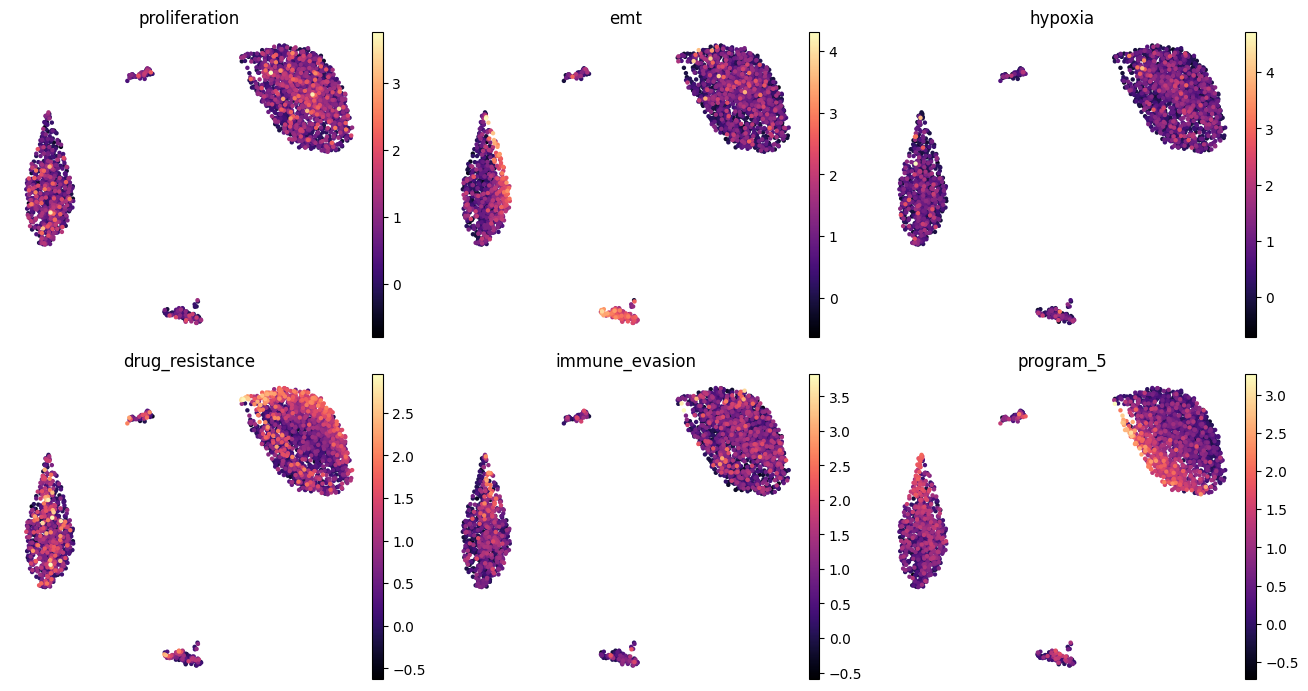

In [12]:
U10.obs[progs] = np.asarray(truth[U10.obs_names].obsm["program"])
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for name, ax in zip(progs, axes.ravel()):
    sc.pl.umap(U10, color=name, ax=ax, show=False, frameon=False, title=name, cmap="magma")
plt.tight_layout()

### inferCNV

inferCNV reads copy number off the expression by smoothing along the genome against a normal
reference. The generated cells carry their true per-segment copy number, so the inference can be
scored directly. It runs in its own `iscc-infercnv` environment; the cell below is skipped where
that environment is absent.

malignant-vs-normal AUC : 0.979
mean per-segment r (single cell): 0.268
clone-level r (segments with real CN variation): 0.470


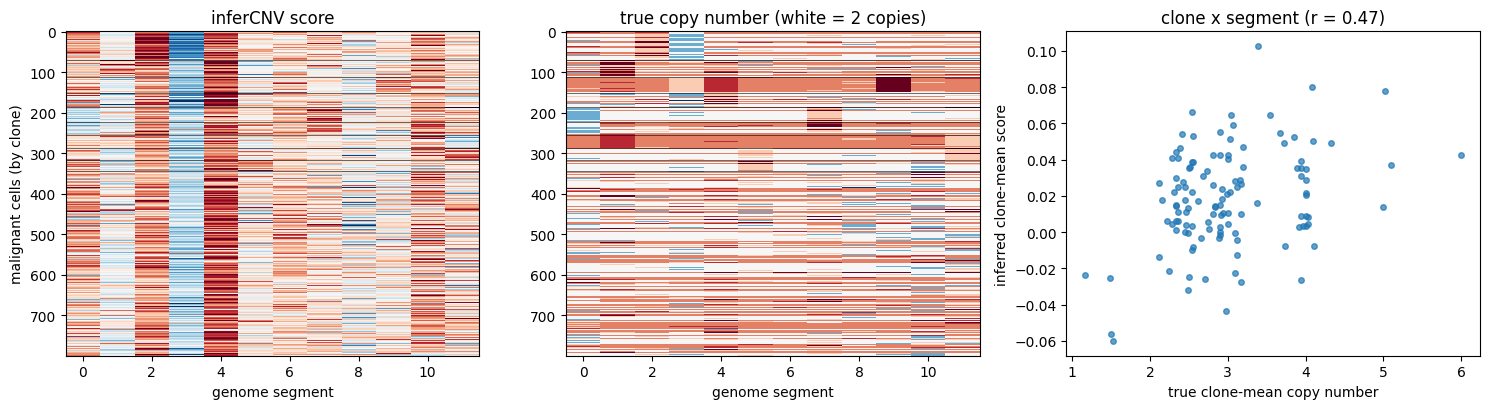

In [13]:
if not C.infercnv_available():
    print("inferCNV environment not found — skipping (expected at ~/miniconda3/envs/iscc-infercnv).")
else:
    # `%matplotlib inline` exports MPLBACKEND, which the separate inferCNV environment cannot read.
    os.environ.pop("MPLBACKEND", None)
    icnv = C.build_infercnv_inputs(tumor, n_cancer=800, n_normal=300, protocol="10x", seed=0)
    res = C.run_infercnv(icnv, os.path.join(tempfile.mkdtemp(), "infercnv"))

    mal = (icnv.obs["cell_type"] == "malignant").values
    lab = pd.Categorical(truth.obs["clone"].reindex(icnv.obs_names)[mal].astype(str))
    score = C.score_infercnv(res, icnv.obsm["true_seg_cn"], clone_labels=lab.codes)

    order = np.argsort(lab.codes, kind="stable")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    axes[0].imshow(res["seg_score"][mal][order], aspect="auto", cmap="RdBu_r", vmin=-0.1, vmax=0.1,
                   interpolation="nearest")
    axes[0].set(title="inferCNV score", xlabel="genome segment", ylabel="malignant cells (by clone)")
    axes[1].imshow(np.asarray(icnv.obsm["true_seg_cn"], float)[mal][order], aspect="auto",
                   cmap="RdBu_r", norm=TwoSlopeNorm(vcenter=2, vmin=0, vmax=6),
                   interpolation="nearest")
    axes[1].set(title="true copy number (white = 2 copies)", xlabel="genome segment")
    for ax in axes[:2]:                                   # clone boundaries
        for b in np.flatnonzero(np.diff(lab.codes[order])) + 1:
            ax.axhline(b, color="k", lw=0.4)
    axes[2].scatter(score["clone_true"].ravel(), score["clone_inferred"].ravel(), s=16, alpha=0.7)
    axes[2].set(xlabel="true clone-mean copy number", ylabel="inferred clone-mean score",
                title=f"clone x segment (r = {score['clone_level_r']:.2f})")
    plt.tight_layout()

    print(f"malignant-vs-normal AUC : {score['malignant_normal_auc']:.3f}")
    print(f"mean per-segment r (single cell): {score['mean_segment_r']:.3f}")
    print(f"clone-level r (segments with real CN variation): {score['clone_level_r']:.3f}")

inferCNV tells malignant from normal almost perfectly and recovers the direction of each segment's
copy number, but the single-cell correlation is modest: averaging cells into clones nearly doubles
it. Copy number from expression is a clone-level readout, not a per-cell one.

## 4. Smart-seq3

Same dissociation, plate protocol. Smart-seq3 is deeper, has almost no ambient RNA and no dropout,
and — unlike 10x — has real plate structure: cells are index-sorted one per well onto `n_wells`-well
plates, and `plate_sigma` gives every cell on a plate a **shared** depth offset.

| parameter | 10x | Smart-seq3 |
|---|---|---|
| `mu_lib` | 4000 | 8000 |
| `dispersion` | 0.30 | 0.15 |
| `dropout_mid` | 1.5 | 0 (off) |
| `ambient_frac` | 0.05 | 0.005 |
| `n_wells` / `n_plates` | 0 (no plates) | 384 / as many as needed |
| `well_sigma` | 0 | 0.15 |
| `plate_sigma` | — | 0 by default; set it to switch the plate offset on |

plate layout: {'n_plates': 4, 'n_wells': 384, 'n_rows': 16, 'n_cols': 24}


,plate,plate_index,well,well_row,well_col,n_counts
cell,,,,,,
C4473,batch7_P0,0,A01,0,0,9178
C5139,batch7_P0,0,A02,0,1,18572
C6998,batch7_P0,0,A03,0,2,4740
C3874,batch7_P0,0,A04,0,3,7537
C5280,batch7_P0,0,A05,0,4,6025


plate share of log-depth variance: 0.001 at plate_sigma=0 -> 0.143 at plate_sigma=0.2
per-plate median counts: [6693, 6340, 5943, 4026] (flat: [6641, 6778, 6809, 6818])
Smart-seq3: median 5707 counts, 1434 genes/cell, 76% zeros, 1.0% doublets


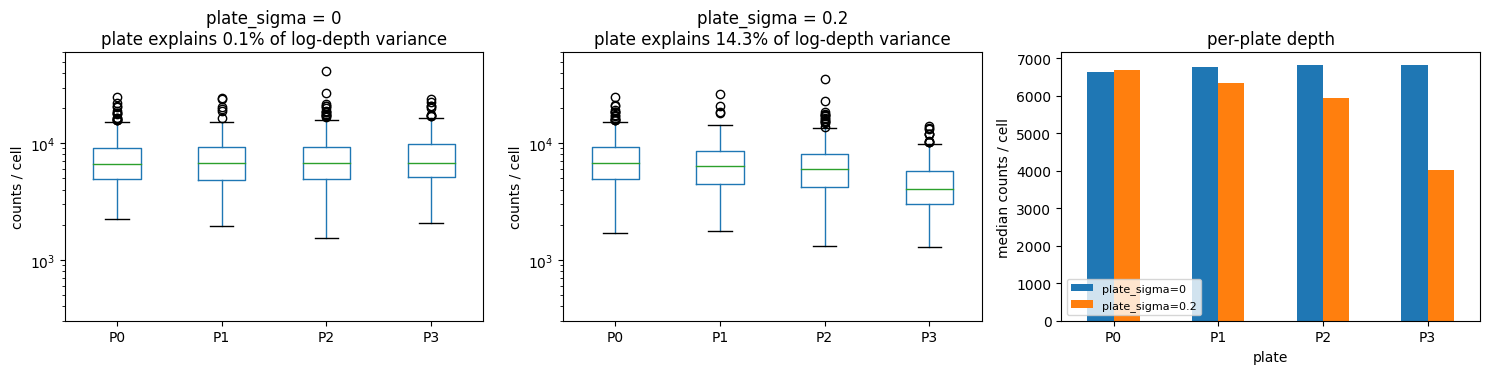

In [14]:
kw = dict(protocol="smartseq3", n_cells=1152, n_plates=4, seed=7)
ss3_flat = scRNA(plate_sigma=0.0, **kw).run(disso).to_anndata()   # plates as bookkeeping only
ss3 = scRNA(plate_sigma=0.2, **kw).run(disso).to_anndata()        # plate-nested depth
for a in (ss3, ss3_flat):
    a.obs["cell_type"] = truth.obs["cell_type"].reindex(a.obs_names).values
    a.obs["clone"] = truth.obs["clone"].reindex(a.obs_names).values

print("plate layout:", ss3.uns["plate_layout"])
display(ss3.obs[["plate", "plate_index", "well", "well_row", "well_col", "n_counts"]].head())

def plate_share(a):
    # Share of the log library-size variance explained by which plate the cell was prepared on.
    lg = np.log(a.obs["n_counts"].values)
    m = pd.Series(lg).groupby(a.obs["plate"].astype(str).values).transform("mean").values
    return 1 - ((lg - m) ** 2).sum() / ((lg - lg.mean()) ** 2).sum()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, a, ttl in [(axes[0], ss3_flat, "plate_sigma = 0"), (axes[1], ss3, "plate_sigma = 0.2")]:
    a.obs.boxplot(column="n_counts", by="plate", ax=ax, grid=False)
    ax.set(xlabel="", ylabel="counts / cell", yscale="log",
           title=f"{ttl}\nplate explains {plate_share(a):.1%} of log-depth variance", ylim=(3e2, 6e4))
    ax.set_xticklabels([t.get_text().split("_")[-1] for t in ax.get_xticklabels()])
med = pd.DataFrame({"plate_sigma=0": ss3_flat.obs.groupby("plate", observed=True)["n_counts"].median(),
                    "plate_sigma=0.2": ss3.obs.groupby("plate", observed=True)["n_counts"].median()})
med.index = [i.split("_")[-1] for i in med.index]
med.plot.bar(ax=axes[2], rot=0, legend=False)
axes[2].legend(fontsize=8, loc="lower left")
axes[2].set(xlabel="plate", ylabel="median counts / cell", title="per-plate depth")
fig.suptitle("")
plt.tight_layout()

print(f"plate share of log-depth variance: {plate_share(ss3_flat):.3f} at plate_sigma=0 -> "
      f"{plate_share(ss3):.3f} at plate_sigma=0.2")
print(f"per-plate median counts: {list(med['plate_sigma=0.2'].astype(int))} "
      f"(flat: {list(med['plate_sigma=0'].astype(int))})")
print(f"Smart-seq3: median {ss3.obs['n_counts'].median():.0f} counts, "
      f"{ss3.obs['n_genes'].median():.0f} genes/cell, {(ss3.X == 0).mean():.0%} zeros, "
      f"{ss3.obs['is_doublet'].mean():.1%} doublets")

With `plate_sigma=0` the plates are pure bookkeeping and the four boxes sit on top of each other.
Turn it on and each plate acquires its own depth level — a batch effect nested inside a single
experiment, which is exactly the structure plate-based data has in practice.

plate silhouette: -0.029  (0 = plates do not split the embedding)


,sil_cell_type,sil_clone,knn_clone,knn_chance
10x counts,0.669,-0.063,0.408,0.348
ground truth,0.905,-0.092,0.593,0.348
Smart-seq3 counts,0.813,-0.155,0.470,0.346


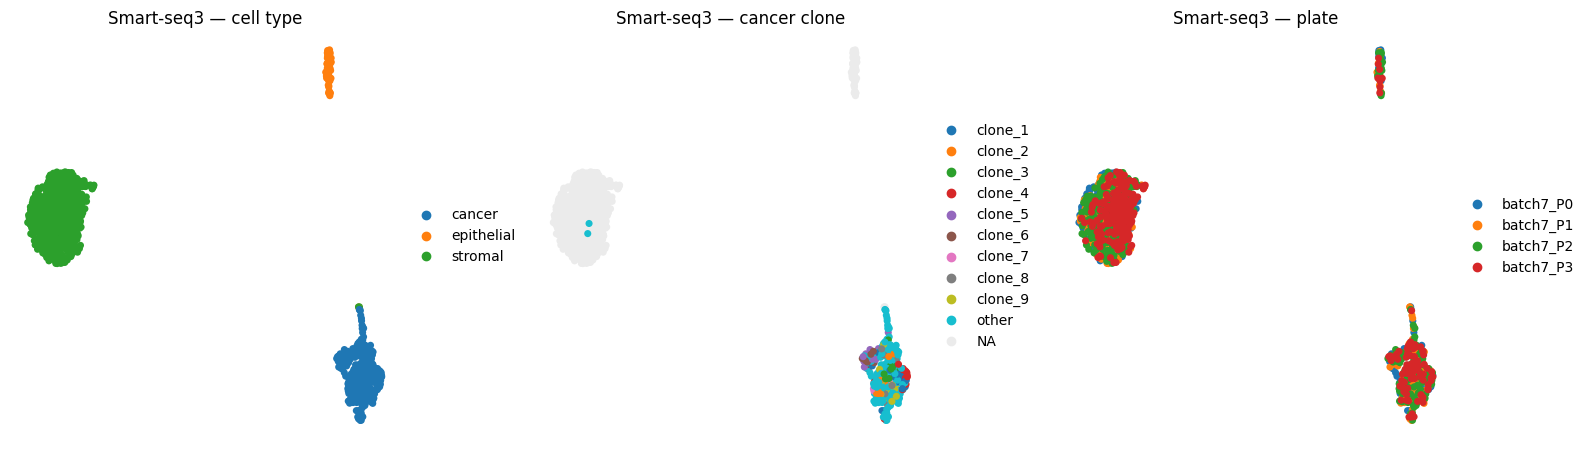

In [15]:
Uss = umap_of(ss3)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, key, ttl in [(axes[0], "cell_type", "cell type"), (axes[1], "clone", "cancer clone"),
                     (axes[2], "plate", "plate")]:
    sc.pl.umap(Uss, color=key, ax=ax, show=False, frameon=False, title=f"Smart-seq3 — {ttl}",
               na_color="0.92")
plt.tight_layout()

can = Uss[Uss.obs["cell_type"] == "cancer"]
p, chance = knn_purity(can, "clone")
rows["Smart-seq3 counts"] = dict(sil_cell_type=separation(Uss, "cell_type"),
                                 sil_clone=separation(can, "clone"), knn_clone=p, knn_chance=chance)
print(f"plate silhouette: {separation(Uss, 'plate'):.3f}  (0 = plates do not split the embedding)")
display(pd.DataFrame(rows).T.round(3))

Deeper counts and no dropout buy a slightly cleaner cell-type embedding than 10x, and the clone
picture is unchanged — still no expression structure. The plate offset shifts depth without
splitting the embedding, because normalising by library size removes most of it.

## 5. Estimating the parameters from real data

`estimate_rna` fits the assay hyper-parameters from a real count matrix. Only some of them are
identifiable from counts alone — `est.fitted` lists what was actually estimated and `est.carried`
what came from the protocol preset. Ambient fraction and doublet rate, in particular, are **not**
fitted: they are protocol priors.

In [16]:
pbmc = sc.read_h5ad(os.path.join(REPO, "data", "pbmc3k_raw.h5ad"))
est = estimate_rna(pbmc, protocol="10x")

print(f"PBMC3k: {est.n_cells} cells x {est.n_genes} genes")
print("fitted from the data :", est.fitted)
print("carried from the 10x preset:", est.carried)

h = pd.Series(est.hypers.__dict__).drop("protocol")
display(pd.DataFrame({"value": h, "source": ["fitted" if k in est.fitted else "preset" for k in h.index]}))
print(f"\nlibrary-size CV {est.cv_lib:.2f}")

PBMC3k: 2700 cells x 32738 genes
fitted from the data : ['mu_lib', 'sigma_lib', 'dispersion', 'dropout_mid']
carried from the 10x preset: ['ambient_frac', 'doublet_rate', 'kappa', 'well_sigma', 'n_wells', 'n_plates', 'plate_sigma', 'sigma_batch', 'depth_batch_sigma']


,value,source
sigma_batch,0.1,preset
mu_lib,2366.90037,fitted
sigma_lib,0.431431,fitted
dispersion,0.608158,fitted
ambient_frac,0.05,preset
doublet_rate,0.05,preset
dropout_mid,0.93927,fitted
dropout_shape,1.058843,preset
well_sigma,0.0,preset
n_wells,0,preset



library-size CV 0.46


median library size: PBMC3k 2197 | simulated 1210
CV: PBMC3k 0.46 | simulated 0.63


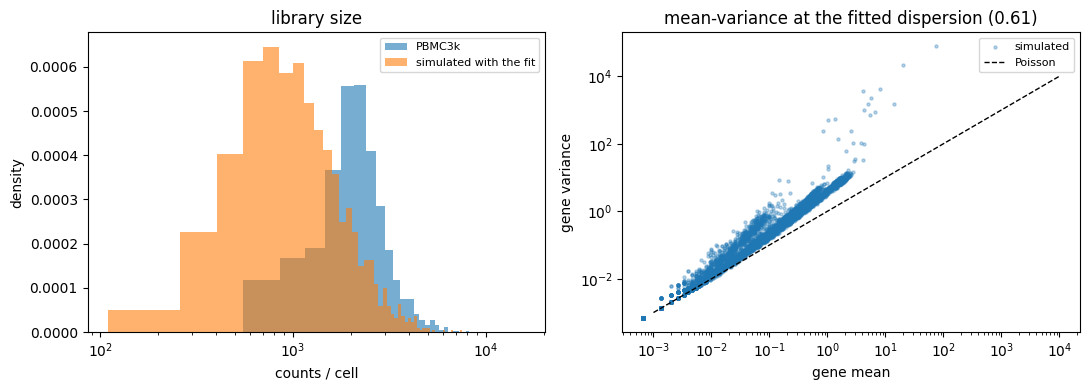

In [17]:
# Simulate with the fitted parameters and compare the two library-size distributions.
sim = scRNA(protocol="10x", n_cells=1500, mu_lib=est.hypers.mu_lib, sigma_lib=est.hypers.sigma_lib,
            dispersion=est.hypers.dispersion, dropout_mid=est.hypers.dropout_mid,
            seed=5).run(disso).to_anndata()
real_lib = np.asarray(pbmc.X.sum(1)).ravel()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(real_lib, bins=50, alpha=0.6, density=True, label="PBMC3k")
axes[0].hist(sim.obs["n_counts"], bins=50, alpha=0.6, density=True, label="simulated with the fit")
axes[0].set(xlabel="counts / cell", ylabel="density", title="library size", xscale="log")
axes[0].legend(fontsize=8)
axes[1].scatter(sim.X.mean(0), sim.X.var(0), s=5, alpha=0.3, label="simulated")
axes[1].plot(lim, lim, "k--", lw=1, label="Poisson")
axes[1].set(xscale="log", yscale="log", xlabel="gene mean", ylabel="gene variance",
            title=f"mean-variance at the fitted dispersion ({est.hypers.dispersion:.2f})")
axes[1].legend(fontsize=8)
plt.tight_layout()

print(f"median library size: PBMC3k {np.median(real_lib):.0f} | simulated {sim.obs['n_counts'].median():.0f}")
print(f"CV: PBMC3k {real_lib.std() / real_lib.mean():.2f} | "
      f"simulated {sim.obs['n_counts'].std() / sim.obs['n_counts'].mean():.2f}")

The fitted depth and overdispersion put the simulated libraries in the same range as the real ones,
but not on top of them: the simulated cells carry the tumour's expression profile, not PBMC biology,
and the fitted dropout removes counts after the library is drawn, so the realised median lands below
`mu_lib`. What the fit cannot do at all is invent the parts counts do not identify — ambient
fraction, doublet rate and batch strength stay at their preset values, and a simulation is only as
honest about those as the preset is.